# Chest X-Ray Pneumonia Detection with CNNs and Transfer Learning

In this project, I build and evaluate a deep learning system to classify chest X-ray images as **normal** or **pneumonia** using a publicly available Kaggle dataset. Pneumonia detection is a high-impact medical imaging task where model reliability, generalization, and the type of errors made (false negatives vs false positives) are often more important than accuracy alone. Class imbalance and subtle visual patterns make this problem particularly challenging and well suited for studying model robustness.

To analyze how architectural choices impact performance, I implement and compare two approaches:

*   **A Convolutional Neural Network (CNN) trained from scratch**
    
    This model serves as a baseline to observe learning behaviour on limited medical data. I train it with a weighted loss to address class imbalance and evaluate the impact of **regularization choices such as weight decay (L2) and early stopping**.

*  **A fine-tuned ResNet18 model using transfer learning**
    
    ResNet18 leverages pretrained representations learned on ImageNet. By fine-tuning the last residual block and the classification head for binary prediction, I evaluate how pretrained features improve **generalization**, **stability**, and **error balance in medical imaging**.

Beyond predictive performance, the project focuses on a comprehensive evaluation across multiple dimensions: generalization on unseen data (test accuracy and ROC-AUC), class-specific performance (precision/recall and confusion matrix), and interpretability using Grad-CAM on false negatives and false positives. This combined quantitative and qualitative analysis highlights why transfer learning is often preferable for medical imaging tasks and demonstrates how model selection should be guided by model behaviour—not accuracy alone.

# SETUP

In [2]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 94.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=e41a56c7cd3e83771ae851d5fb617de29924954126c52ee25429bf0783914d7d
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
pip install opencv-python

In [3]:
#IMPORT LIBRAIRIES

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from PIL import Image
from torchvision import models
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torch.utils.data import Subset
from collections import Counter
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import shutil
import os
import random
from google.colab import drive
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

SKIP_TRAINING = True # False if retrain


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:

# Detect Colab
IN_COLAB = "COLAB_GPU" in os.environ or "COLAB_TPU_ADDR" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # persistent in Drive
    BASE_DIR = "/content/drive/MyDrive/ChestXrayProject"
    DATA_DIR = os.path.join(BASE_DIR, "data")
    MODEL_DIR = os.path.join(BASE_DIR, "models")
    OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")
else:
    # local repo
    PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
    DATA_DIR = os.path.join(PROJECT_DIR, "data")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")
    OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
DATA_DIR: /content/drive/MyDrive/ChestXrayProject/data
MODEL_DIR: /content/drive/MyDrive/ChestXrayProject/models
OUTPUT_DIR: /content/drive/MyDrive/ChestXrayProject/outputs


In [ ]:
import os, zipfile

zip_path = os.path.join(DATA_DIR, "archive.zip")
print("zip_path:", zip_path)

if not os.path.exists(zip_path):
    raise FileNotFoundError(f"archive.zip not found in DATA_DIR: {zip_path}")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Extracted to:", DATA_DIR)
print("DATA_DIR content:", os.listdir(DATA_DIR)[:30])

zip_path: /content/drive/MyDrive/ChestXrayProject/data/archive.zip


In [6]:
# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DATA LOADING

In [7]:



train_dir = os.path.join(DATA_DIR, "chest_xray", "train")
test_dir = os.path.join(DATA_DIR, "chest_xray", "test")

assert os.path.isdir(train_dir), f"Missing folder: {train_dir}"
assert os.path.isdir(test_dir),  f"Missing folder: {test_dir}"

print("Train classes:", os.listdir(train_dir))
print("Test classes:", os.listdir(test_dir))


Train classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']


# EXPLORATORY DATA ANALYSIS (EDA)

In [ ]:
#PREPROCESSING-TRANSFORMATIONS FOR DATA EXPLORATION

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])


{'NORMAL': 0, 'PNEUMONIA': 1}
Class names: ['NORMAL', 'PNEUMONIA']

Train dataset balance check:
PNEUMONIA: 3875
NORMAL: 1341

Validation dataset balance check:
NORMAL: 8
PNEUMONIA: 8

Test dataset balance check:
PNEUMONIA: 390
NORMAL: 234
Train Size: 5216
Validation size: 16
Test size: 624
Total Data Size: 5856
torch.Size([64, 3, 224, 224]) torch.Size([64])


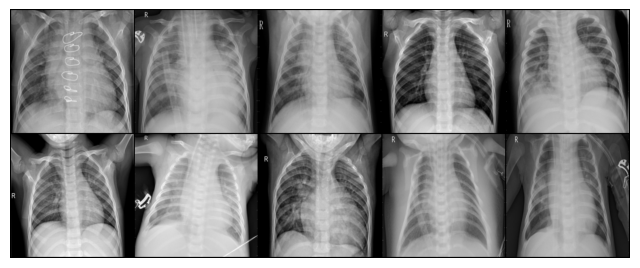

In [ ]:



# DATA EXPLORATION

train_dataset = ImageFolder(os.path.join(DATA_DIR, "chest_xray", "train"), transform=transform)
val_dataset   = ImageFolder(os.path.join(DATA_DIR, "chest_xray", "val"),   transform=transform)
test_dataset  = ImageFolder(os.path.join(DATA_DIR, "chest_xray", "test"),  transform=transform)

#class name, balance for train, val and test sets


# class name, balance for train and test sets
print(train_dataset.class_to_idx)
print("Class names:", train_dataset.classes)



print ("\nTrain dataset balance check:")
counts = pd.Series(train_dataset.targets).value_counts()
for label, count in counts.items():
    class_name = train_dataset.classes[label]
    print(f"{class_name}: {count}")

print ("\nValidation dataset balance check:")
counts = pd.Series(val_dataset.targets).value_counts()
for label, count in counts.items():
    class_name = val_dataset.classes[label]
    print(f"{class_name}: {count}")

print ("\nTest dataset balance check:")
counts = pd.Series(test_dataset.targets).value_counts()
for label, count in counts.items():
    class_name = test_dataset.classes[label]
    print(f"{class_name}: {count}")

#data size
print ("Train Size:", len(train_dataset))
print ("Validation size:", len(val_dataset))
print ("Test size:", len(test_dataset))
print ("Total Data Size:", len(train_dataset) + len(val_dataset) + len(test_dataset))

#Load a batch and showing shapes
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
for i, l in train_loader:
  print (i.shape, l.shape)
  break

#Visualize 10 first images
images, labels = next(iter(train_loader))
img_grid = torchvision.utils.make_grid(images[:10], nrow=5, normalize=True)

# Plot the grid
plt.figure(figsize=(8, 4))
plt.imshow(img_grid.permute(1, 2, 0))  # convert from CxHxW to HxWxC
plt.axis('off')
plt.show()


# **Exploratory Analysis**

**The training dataset** shows a strong class imbalance, with the **Pneumonia** class appearing almost three times more frequently than **Normal**. This imbalance can cause the model to favor the majority class, so I will address it by using **a weighted loss function** to give more importance to the minority class.

I chose not to use oversampling or GAN-generated images because oversampling would duplicate a small number of NORMAL images and risk overfitting, while GANs require complex training and would introduce synthetic medical images that are hard to validate clinically. Weighted loss keeps the dataset untouched and is the most stable and realistic choice for this project.


In addition to this, I will apply **data augmentation** on the training set to introduce variability and help reduce overfitting by exposing the model to slightly different versions of the same images.

**The validation set** is balanced, but it is extremely small (only 16 images). Such a small set cannot provide reliable validation metrics and will likely produce unstable accuracy and loss values during training. To address this, **I will reconstruct a new validation set by taking 10% of the training data and reserving it as a more representative validation split.**

Another important observation is that the X-ray images appear **grayscale but are stored as 3-channel RGB**. This behavior is expected because PIL loads JPEG files in RGB format by default. The three channels contain identical grayscale information, so no visual information is altered. This format is especially convenient because I will later fine-tune ResNet18, which requires 3-channel input.


# **Dataset Splitting and Transformation Strategy**

The original Kaggle validation set is too small to provide meaningful metrics, so I replaced it with a new validation split made from 10% of the training data. I also apply different transforms depending on the dataset: the training set uses data augmentation to reduce overfitting, while the validation and test sets use clean, non-augmented transforms to ensure that performance is evaluated fairly and consistently.

In [8]:
## Final Data Transformations for Training and Evaluation

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),        # Random rotation (degrees)
    transforms.RandomAffine(degrees=0,
                            translate=(0.1, 0.1),  # Random horizontal and vertical shift
                            scale=(0.9, 1.1)),    # Random zoom
    transforms.RandomHorizontalFlip(),    # Random horizontal flip
    transforms.ToTensor(),                # Convert to tensor
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))  # Normalize pixel values to [-1, 1]
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])




In [9]:
## Dataset splitting


train_dataset_full = ImageFolder(os.path.join(DATA_DIR,"chest_xray", "train"), transform=transform_train)
val_dataset_full   = ImageFolder(os.path.join(DATA_DIR, "chest_xray", "train"), transform=transform_val)
test_dataset        = ImageFolder(os.path.join(DATA_DIR, "chest_xray", "test"),  transform=transform_test)


n_samples = len (train_dataset_full)
indices = list(range(n_samples))

#import random
#random.shuffle(indices)

split = int(0.9 * n_samples)
train_indices = indices[:split]
val_indices   = indices[split:]

train_subset = Subset (train_dataset_full, train_indices)
val_subset = Subset (val_dataset_full, val_indices)

train_loader = DataLoader (train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader (val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader (test_dataset, batch_size=64, shuffle=False)

In [10]:

#DEFINE CNN

class ChestXRayCNN (nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.bn2 = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
    self.bn3 = nn.BatchNorm2d(128)

    self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
    self.bn4 = nn.BatchNorm2d(256)

    self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

    self.flatten = nn.Flatten()
    self.drop = nn.Dropout(p=0.3)

    self.fc1 = nn.Linear(256*14*14, 512)

    self.fc2 = nn.Linear(512, 1)

  def forward (self, x):
    x = torch.relu(self.bn1(self.conv1(x)))
    x = self.pool(x)

    x = torch.relu(self.bn2(self.conv2(x)))
    x = self.pool(x)

    x = torch.relu(self.bn3(self.conv3(x)))
    x = self.pool(x)

    x = torch.relu(self.bn4(self.conv4(x)))
    x = self.pool(x)

    x = self.flatten (x)
    x = self.drop(x)

    x = torch.relu(self.fc1(x))
    x = self.drop(x)
    x = self.fc2(x)
    return x




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# **Experiment 1 vs Experiment 2**

In the following experiments, I evaluate the training and generalization behavior of the custom CNN model for chest X-ray classification. Different training strategies are tested and compared using validation performance to select the best model for final evaluation.

#EXPERIMENT 1 — CUSTOM CNN (baseline)

In [11]:
#empty lists

train_losses = []
train_accs = []
val_losses = []
val_accs = []

In [12]:
#best model
best_val_acc = 0.0
best_model_path = os.path.join(MODEL_DIR, "best_cnn.pth")


In [13]:
model = ChestXRayCNN ()
model.to(device)


ChestXRayCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

In [14]:
counts = Counter (train_dataset_full.targets)  #apply weighted loss to handle imbalance
pos_weight=torch.tensor([counts[0]/counts[1]], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
# Train, validation loops

epochs = 50
patience = 5        # stop if no improvement for 5 epochs
min_delta = 1e-4    # minimum improvement in val_acc to count as "better"
epochs_no_improve = 0

#  Skip training if best model already exists
if SKIP_TRAINING and os.path.exists(best_model_path):
    print("Skipping training. Loading best CNN (Exp1):", best_model_path)
    model.load_state_dict(torch.load(best_model_path, map_location=device))

else:
    for epoch in range(epochs):  #training loop
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (images, target) in enumerate(train_loader):
            images = images.to(device)
            target = target.to(device=device, dtype=torch.float)

            optimizer.zero_grad()
            output = model(images)
            output = output.squeeze(1)

            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            correct += (pred == target).sum().item()
            total += target.size(0)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # accuracy, avg_loss
        train_accuracy = correct / total
        avg_train_loss = total_loss / len(train_loader)

        model.eval()   #Evaluation loop
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_idx, (images, target) in enumerate(val_loader):
                images = images.to(device)
                target = target.to(device=device, dtype=torch.float)
                output = model(images)
                output = output.squeeze(1)

                prob = torch.sigmoid(output)
                pred = (prob>=0.5).float()
                correct += (pred == target).sum().item()
                total += target.size(0)

                loss = criterion(output, target)
                total_loss += loss.item()

        # accuracy, avg_loss
        val_accuracy = correct / total
        avg_val_loss = total_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)

        if val_accuracy > best_val_acc + min_delta:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), best_model_path)
            print("Saved new best model!")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} |  "
            f"No improve: {epochs_no_improve}/{patience}"
        )

        # early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Acc: {best_val_acc:.4f}")
            break


KeyboardInterrupt: 

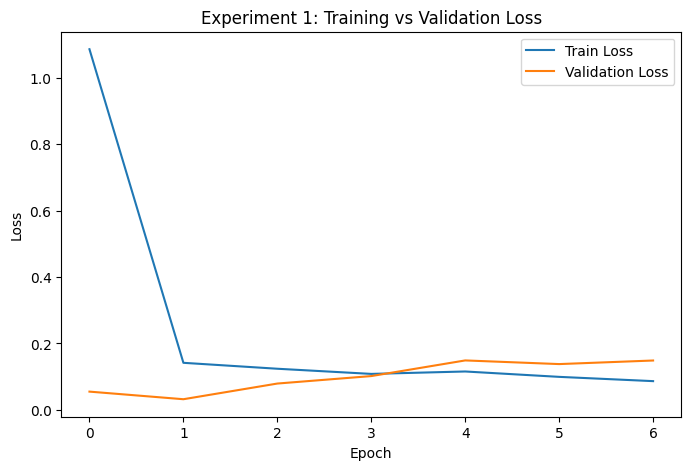

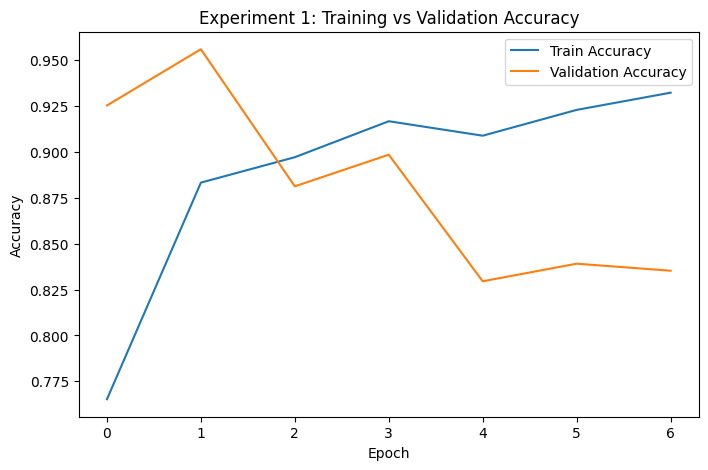

In [ ]:
#learning curves
plt.figure (figsize=(8,5)) #train vs validation loss
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 1: Training vs Validation Loss")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "exp1_loss_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure (figsize=(8,5)) #train vs validation accuracy
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 1: Training vs Validation Accuracy")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "exp1_accuracy_curve.png"), dpi=200, bbox_inches="tight")
plt.show()



# Training and Validation Results (Experiment 1 — baseline CNN + weighted BCE)

I trained the CNN with a maximum of 50 epochs, but I used early stopping to stop training when the validation accuracy stopped improving (patience = 5, min_delta = 1e-4). Training stopped at epoch 7, because the validation accuracy did not beat the best score for 5 consecutive epochs.

The model improved very quickly in the first epochs:

**Epoch 1:** Train Acc = 0.7652, Val Acc = 0.9253

**Epoch 2:** Train Acc = 0.8833, Val Acc = 0.9559, Val Loss = 0.0319

After epoch 2, validation performance became unstable. While training accuracy kept increasing (up to 0.9323 by epoch 7), validation accuracy dropped noticeably (for example 0.8812 at epoch 3 and 0.8352 at epoch 7). At the same time, validation loss increased steadily after epoch 2 (from 0.0319 to around 0.1485), while training loss continued decreasing.

From the learning curves:

* The training loss curve shows a sharp drop between epoch 1 and 2, followed by a gradual decrease.

* The validation loss curve reaches its minimum at epoch 2 and then increases consistently.

* The accuracy curves show a widening gap after epoch 2, with training accuracy rising and validation accuracy declining.

This pattern clearly indicates the beginning of overfitting after epoch 2. The model continues to fit the training data better, but generalization performance does not improve and becomes unstable.

To stay consistent and avoid overfitting, I keep the checkpoint from epoch 2, because it gives the best validation accuracy (0.9559) and the lowest validation loss (0.0319). This represents the best generalization performance observed during training.


# Next Step: Adding L2 Regularization (Experiment 2)

Next, I will test L2 regularization (weight decay). The goal is to see whether L2 makes training more stable and improves generalization, especially after the first few epochs.

To make the comparison fair, I will keep the same training setup (same model, same loss, same learning rate), and I will also use the same early stopping strategy (patience = 5, min_delta = 1e-4). This way, both experiments are evaluated under the same stopping rule, and differences in performance can be attributed more reliably to regularization.

# **EXPERIMENT 2 — CUSTOM CNN + L2**

In [16]:
#empty lists

train_losses2 = []
train_accs2 = []
val_losses2 = []
val_accs2 = []

In [17]:
# best model for experiment 2 (L2)
best_val_acc2 = 0.0
best_model_path2 = os.path.join(MODEL_DIR, "best_cnn_l2.pth")


In [18]:

model = ChestXRayCNN ()
model.to(device)

counts = Counter (train_dataset_full.targets)
pos_weight=torch.tensor([counts[0]/counts[1]], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.001)  #optimizer with L2

In [ ]:
# Train, validation loops (CNN + L2)

epochs = 50
patience = 5
min_delta = 1e-4
epochs_no_improve = 0

# Skip training if best model already exists
if SKIP_TRAINING and os.path.exists(best_model_path2):
    print("Skipping training. Loading best CNN + L2:", best_model_path2)
    model.load_state_dict(torch.load(best_model_path2, map_location=device))

else:
    for epoch in range(epochs):
        # training loop
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch_idx, (images, target) in enumerate(train_loader):
            images = images.to(device)
            target = target.to(device=device, dtype=torch.float)

            optimizer.zero_grad()
            output = model(images)
            output = output.squeeze(1)

            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()
            correct += (pred == target).sum().item()
            total += target.size(0)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_accuracy = correct / total
        avg_train_loss = total_loss / len(train_loader)

        # validation loop
        model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for batch_idx, (images, target) in enumerate(val_loader):
                images = images.to(device)
                target = target.to(device=device, dtype=torch.float)

                output = model(images)
                output = output.squeeze(1)

                prob = torch.sigmoid(output)
                pred = (prob >= 0.5).float()
                correct += (pred == target).sum().item()
                total += target.size(0)

                loss = criterion(output, target)
                total_loss += loss.item()

        # accuracy, avg_loss
        val_accuracy = correct / total
        avg_val_loss = total_loss / len(val_loader)

        train_losses2.append(avg_train_loss)
        train_accs2.append(train_accuracy)
        val_losses2.append(avg_val_loss)
        val_accs2.append(val_accuracy)

        # save best model + early stopping logic
        if val_accuracy > best_val_acc2 + min_delta:
            best_val_acc2 = val_accuracy
            torch.save(model.state_dict(), best_model_path2)
            print("Saved new best model (CNN + L2)!")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | "
            f"No improve: {epochs_no_improve}/{patience}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Acc: {best_val_acc2:.4f}")
            break


Saved new best model (CNN + L2)!
Epoch 1/50 | Train Loss: 0.9611 | Val Loss: 0.0508 | Train Acc: 0.7744 | Val Acc: 0.9272 | No improve: 0/5
Epoch 2/50 | Train Loss: 0.1489 | Val Loss: 0.0760 | Train Acc: 0.8779 | Val Acc: 0.9023 | No improve: 1/5
Saved new best model (CNN + L2)!
Epoch 3/50 | Train Loss: 0.1138 | Val Loss: 0.0539 | Train Acc: 0.9071 | Val Acc: 0.9310 | No improve: 0/5
Epoch 4/50 | Train Loss: 0.1128 | Val Loss: 0.0705 | Train Acc: 0.9133 | Val Acc: 0.9195 | No improve: 1/5
Saved new best model (CNN + L2)!
Epoch 5/50 | Train Loss: 0.0932 | Val Loss: 0.0251 | Train Acc: 0.9244 | Val Acc: 0.9713 | No improve: 0/5
Epoch 6/50 | Train Loss: 0.1049 | Val Loss: 0.0605 | Train Acc: 0.9152 | Val Acc: 0.9349 | No improve: 1/5
Epoch 7/50 | Train Loss: 0.0935 | Val Loss: 0.1699 | Train Acc: 0.9291 | Val Acc: 0.8391 | No improve: 2/5
Epoch 8/50 | Train Loss: 0.0943 | Val Loss: 0.0626 | Train Acc: 0.9288 | Val Acc: 0.9349 | No improve: 3/5
Epoch 9/50 | Train Loss: 0.0877 | Val Loss: 0

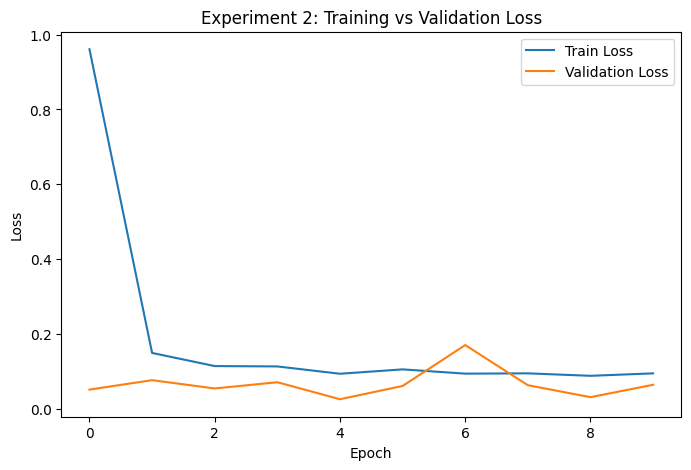

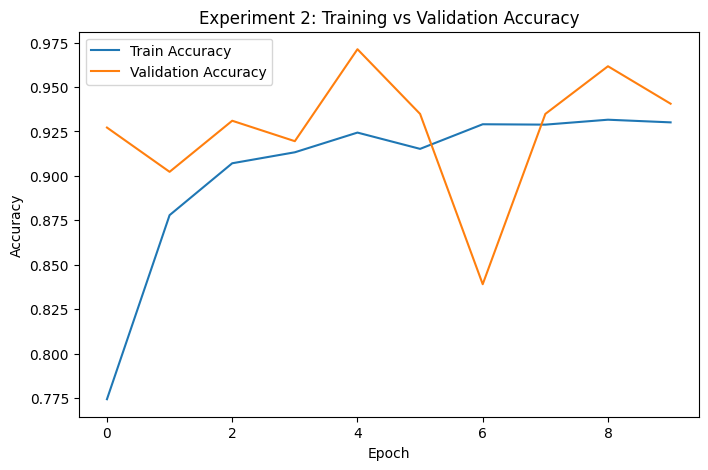

In [ ]:
#learning curves
plt.figure (figsize=(8,5)) #train vs validation loss
plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 2: Training vs Validation Loss")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "exp2_loss_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure (figsize=(8,5)) #train vs validation accuracy
plt.plot(train_accs2, label="Train Accuracy")
plt.plot(val_accs2, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment 2: Training vs Validation Accuracy")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "exp2_accuracy_curve.png"), dpi=200, bbox_inches="tight")
plt.show()


# Results Experiment 2 (CNN + L2 Regularization)

In this second experiment, I trained the same CNN architecture with the same loss function (weighted BCEWithLogitsLoss), but I added L2 regularization through weight_decay = 0.001 in the Adam optimizer. I also used the same early stopping rule as in Experiment 1 (patience = 5, min_delta = 1e-4) to prevent unnecessary training once validation performance stopped improving.

Training ran until epoch 10, when early stopping was triggered. The model reached its best validation performance at epoch 5, with:

* **Best Val Acc = 0.9713**
* **Val Loss = 0.0251**
* **Train Acc (epoch 5) = 0.9244**

In the first epochs, training loss dropped sharply (from 0.9611 to 0.1489 between epoch 1 and 2), and training accuracy increased steadily. Validation accuracy initially fluctuated (0.9272 → 0.9023 → 0.9310), but then improved significantly at epoch 5, where it reached its maximum value.

From the learning curves:

* The training loss decreases quickly and then stabilizes at a relatively low level.

* The validation loss fluctuates more than training loss, but reaches its minimum at epoch 5.

* The accuracy curves show that validation accuracy remains relatively close to training accuracy during the first half of training.

A clear instability appears at epoch 7, where validation accuracy drops to 0.8391 and validation loss spikes (0.1699), while training accuracy continues increasing. This indicates temporary overfitting or sensitivity to mini-batch variation.

After epoch 5, although training accuracy continues to increase slightly (up to 0.9316 at epoch 9), validation accuracy does not surpass the best score obtained at epoch 5. Early stopping correctly restores the best checkpoint from epoch 5.


# MODEL SELECTION (Validation-based)

To select the final model in a fair way, I use the validation set only. Each experiment provides its own best checkpoint, and I select the final model based on the highest validation accuracy.

* **Experiment 1 (no weight decay):** best validation accuracy was **0.9559** (epoch 2).

* **Experiment 2 (with weight decay = 0.001):** best validation accuracy was **0.9713** (epoch 5).

Since validation accuracy is the selection criterion, the final model is the **Experiment 2 checkpoint from epoch 5** (`best_cnn_l2.pth`).

The next step is to run the final test evaluation once using this selected model, and then report test metrics including ROC-AUC.

# **# CNN TEST EVALUATION (Accuracy + ROC-AUC)**


In [19]:
model = ChestXRayCNN()
best_cnn_l2_path = os.path.join(MODEL_DIR, "best_cnn_l2.pth")
model.load_state_dict(torch.load(best_cnn_l2_path, map_location=device))
model.to(device)
model.eval()

print(model.conv1.weight[0,0,0,0])


tensor(-0.1073, device='cuda:0', grad_fn=<SelectBackward0>)


In [22]:
print("Loading:", best_cnn_l2_path)

Loading: /content/drive/MyDrive/ChestXrayProject/models/best_cnn_l2.pth


In [20]:
# Prepare lists for ROC-AUC
all_probs = []
all_preds = []
all_targets = []
FN = []
FP = []

In [21]:
# test loop
total_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, target in test_loader:
        images= images.to(device)
        target = target.to(device=device, dtype=torch.float)

        output= model(images)
        output= output.squeeze(1)

        prob= torch.sigmoid(output)
        pred = (prob >= 0.5).float()

        # Collect for ROC-AUC, confusion, false negative
        all_probs.append(prob.cpu())
        all_preds.append (pred.cpu())

        all_targets.append(target.cpu())


        # Collect FN
        for i in range (len(target)):
          if target [i] == 1 and pred [i] == 0:
            FN.append(images[i].cpu())

        # Collect FP
        for i in range (len(target)):
          if target [i] == 0 and pred [i] == 1:
            FP.append (images[i].cpu())


        correct += (pred == target).sum().item()
        total+= target.size(0)

        loss = criterion(output, target)
        total_loss += loss.item()

# Final metrics
test_accuracy = correct / total
avg_test_loss = total_loss / len(test_loader)

print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")


Test Loss: 1.3817 | Test Accuracy: 0.6811


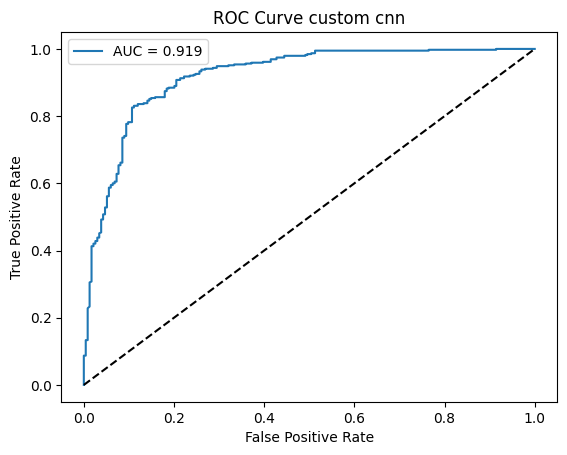

In [23]:
#compute AUC/ROC

y_true = torch.cat (all_targets).numpy ()
y_scores = torch.cat (all_probs).numpy()

fpr, tpr, _ = roc_curve(y_true, y_scores)
auc_ = roc_auc_score(y_true, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc_:.3f}")
plt.plot([0,1], [0,1], 'k--')  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve custom cnn")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_custom_cnn.png"), dpi=200, bbox_inches="tight")

plt.show()


Since the dataset is highly imbalanced (Pneumonia: 3875 vs Normal: 1341), accuracy alone does not fully reflect the model’s performance. With the selected model (Experiment 2 checkpoint), the test loss is **1.3817** and the test accuracy is **0.6811**.


Although **0.6811** accuracy is significantly better than random guessing, accuracy depends on a fixed decision threshold (here 0.5). With imbalanced data, this threshold may not be optimal and can lead to classification errors even when the model has learned meaningful class separation.

A better global view of the model’s discriminative ability is given by the ROC curve. The CNN achieves a strong **ROC-AUC of 0.919**, meaning it can rank pneumonia images higher than normal images in the vast majority of cases.

From the ROC curve, we observe:

* The curve rises very steeply near the origin.
* It stays well above the diagonal random baseline.
* The area under the curve is close to 1, indicating strong class separability.

This shows that the model has learned highly informative features to distinguish pneumonia from normal cases. Even if the default 0.5 threshold does not maximize test accuracy, the high ROC-AUC confirms that the model’s ranking ability is strong and that threshold tuning could further optimize classification performance.


# Phase 2 — CNN INTERPRETABILITY (CM + metrics + FN/FP + Grad-CAM)


In this section, I go beyond overall performance scores and examine **how** the CNN makes its decisions. I use a combination of **confusion matrix analysis** and **class-specific metrics** (especially precision and recall), then I inspect the model’s **false negatives** and **false positives** to understand the types of mistakes it makes. Finally, I apply **Grad-CAM** to visualize which image regions drive the predictions and verify that the network focuses on clinically relevant lung areas rather than shortcuts or artifacts. This step is essential in medical AI because the dataset is imbalanced and because the cost of errors is not symmetric: missing a pneumonia case (false negative) can be much more harmful than raising a false alarm.


[[ 36 198]
 [  1 389]]


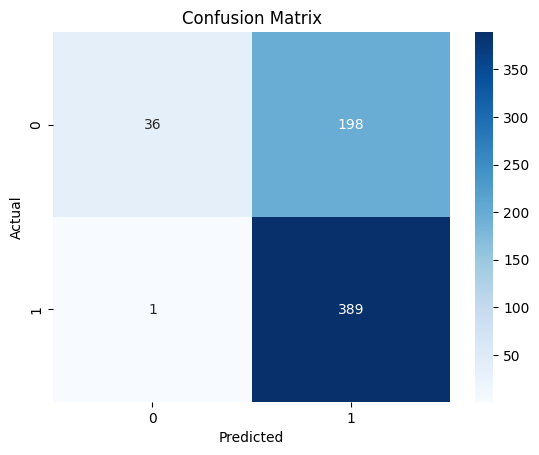

In [24]:
#confusion metrics
y_true = torch.cat (all_targets).numpy ()
y_pred = torch.cat (all_preds).numpy ()

y_true = y_true.astype(int)
y_pred = y_pred.astype(int)


cm = confusion_matrix(y_true, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
print(len(FN), len(FP))


1 198


In [26]:
#(precision/recall)

precision_pos = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
recall_pos    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1_pos        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
bal_acc       = balanced_accuracy_score(y_true, y_pred)

print(f"Precision (Pneumonia=1): {precision_pos:.4f}")
print(f"Recall/Sensitivity (Pneumonia=1): {recall_pos:.4f}")
print(f"F1 (Pneumonia=1): {f1_pos:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal (0)", "Pneumonia (1)"], zero_division=0))

Precision (Pneumonia=1): 0.6627
Recall/Sensitivity (Pneumonia=1): 0.9974
F1 (Pneumonia=1): 0.7963
Balanced Accuracy: 0.5756

Classification report:

               precision    recall  f1-score   support

   Normal (0)       0.97      0.15      0.27       234
Pneumonia (1)       0.66      1.00      0.80       390

     accuracy                           0.68       624
    macro avg       0.82      0.58      0.53       624
 weighted avg       0.78      0.68      0.60       624



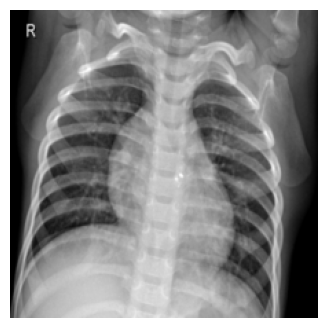

In [27]:
#VISUALIZE FALSE NEGATIVES

tensor_FN = torch.stack(FN)

img_grid = torchvision.utils.make_grid(tensor_FN, nrow=4, normalize=True)

# Plot the grid
plt.figure(figsize=(8, 4))
plt.imshow(img_grid.permute(1, 2, 0))  # convert from CxHxW to HxWxC
plt.axis('off')

plt.savefig(os.path.join(OUTPUT_DIR, "visualize_cnn_fn.png"), dpi=200, bbox_inches="tight")
plt.show()

In [28]:

# grad-CAM

# model
model = ChestXRayCNN()

best_cnn_l2_path = os.path.join(MODEL_DIR, "best_cnn_l2.pth")
model.load_state_dict(torch.load(best_cnn_l2_path, map_location=device))  # load the best model

model.to(device)
model.eval()


ChestXRayCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

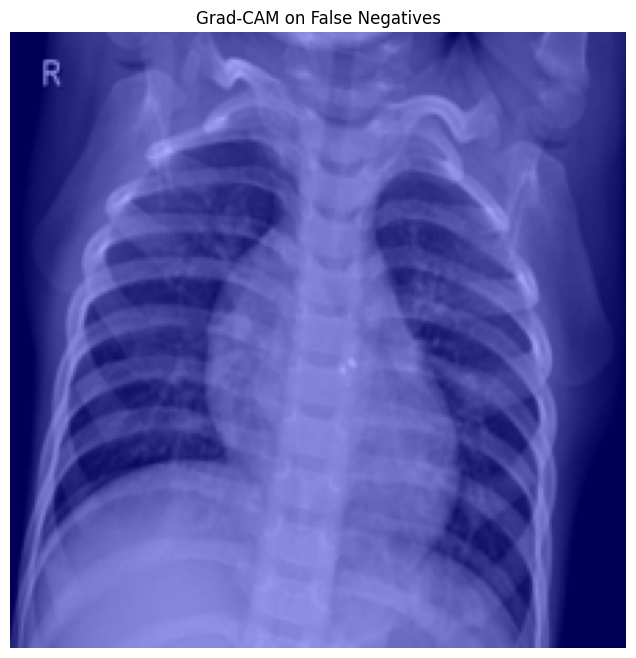

In [29]:
#Grad-CAM on FN

# Pick last conv layer
target_layer = model.conv4

# Loop through FN images
cam = GradCAM(model=model, target_layers=[target_layer])

FN_to_visualize = FN [:8]
visualizations = []

for idx, img_tensor in enumerate(FN_to_visualize):
  input_tensor = img_tensor.unsqueeze(0).to(device)

  img_np = img_tensor.permute(1,2,0).numpy()
  img_np = (img_np * 0.5) + 0.5           # unnormalize to [0,1]
  img_np = np.clip(img_np, 0, 1)

    # Compute Grad-CAM
  grayscale_cam = cam(input_tensor=input_tensor)[0]  # shape: H x W
  visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

  #make grid to see the images
  vis_tensor = torch.from_numpy(visualization).permute(2, 0, 1)
  visualizations.append(vis_tensor)

grid = make_grid(visualizations, nrow=4)


    # Display

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Grad-CAM on False Negatives")
plt.savefig(os.path.join(OUTPUT_DIR, "cnn_gradcam_fn.png"), dpi=200, bbox_inches="tight")
plt.show()



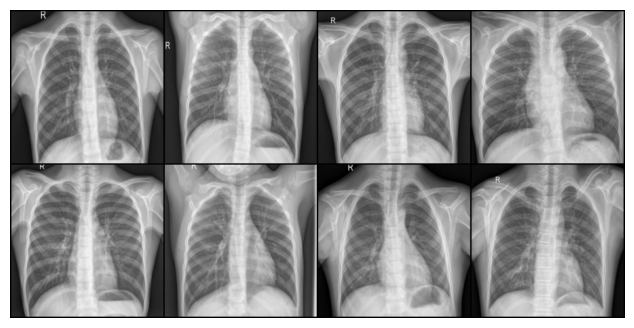

In [30]:
#VISUALIZE FALSE POSITIVES

tensor_FP = torch.stack(FP[:8])

img_grid = torchvision.utils.make_grid(tensor_FP, nrow=4, normalize=True)

# Plot the grid
plt.figure(figsize=(8, 4))
plt.imshow(img_grid.permute(1, 2, 0))  # convert from CxHxW to HxWxC
plt.axis('off')

plt.savefig(os.path.join(OUTPUT_DIR, "visualize_cnn_fp.png"), dpi=200, bbox_inches="tight")
plt.show()

In [31]:
# grad-CAM

# model
model = ChestXRayCNN()
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_cnn_l2.pth"), map_location=device))
model.to(device)
model.eval()


ChestXRayCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (drop): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=50176, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=1, bias=True)
)

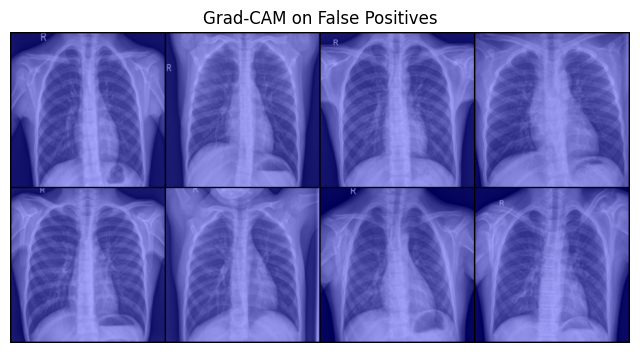

In [32]:
#Grad-CAM on FP

# Pick last conv layer
target_layer = model.conv4

# Loop through FP images
cam = GradCAM(model=model, target_layers=[target_layer])

FP_to_visualize = FP [:8]
visualizations2 = []

for idx, img_tensor2 in enumerate(FP_to_visualize):
  input_tensor2 = img_tensor2.unsqueeze(0).to(device)

  img_np2 = img_tensor2.permute(1,2,0).numpy()
  img_np2 = (img_np2 * 0.5) + 0.5           # unnormalize to [0,1]
  img_np2 = np.clip(img_np2, 0, 1)


    # Compute Grad-CAM
  grayscale_cam2 = cam(input_tensor=input_tensor2)[0]  # shape: H x W
  visualization2 = show_cam_on_image(img_np2, grayscale_cam2, use_rgb=True)

  #make grid to see the images
  vis_tensor2 = torch.from_numpy(visualization2).permute(2, 0, 1)
  visualizations2.append(vis_tensor2)

grid2 = make_grid(visualizations2, nrow=4)


    # Display

plt.figure(figsize=(8, 8))
plt.imshow(grid2.permute(1, 2, 0))
plt.axis("off")
plt.title("Grad-CAM on False Positives")

plt.savefig(os.path.join(OUTPUT_DIR, "cnn_gradcam_fp.png"), dpi=200, bbox_inches="tight")
plt.show()




# ANALYSIS (Custom CNN — Error Analysis + Interpretability)

# 1. Confusion Matrix + Class-Specific Metrics

The confusion matrix reveals a clear asymmetry between false positives and false negatives:

* **True Negatives (TN): 36**
* **False Positives (FP): 198**
* **False Negatives (FN): 1**
* **True Positives (TP): 389**

This means the model almost never misses pneumonia cases, but it predicts pneumonia for a large number of normal images.

This behavior is also reflected in the class-specific metrics:

* **Precision (Pneumonia = 1): 0.6627**
* **Recall / Sensitivity (Pneumonia = 1): 0.9974**
* **F1 (Pneumonia = 1): 0.7963**
* **Balanced Accuracy: 0.5756**

From the classification report:

* Normal (0): precision = 0.97, recall = 0.15, F1 = 0.27
* Pneumonia (1): precision = 0.66, recall = 1.00, F1 = 0.80
* Overall accuracy ≈ 0.68

At threshold **0.5**, the model achieves **very high sensitivity** for pneumonia (only 1 false negative), but comparatively low specificity for normal cases. In a medical screening context, prioritizing sensitivity can be justified because missing a pneumonia case can be more harmful than raising a false alarm. However, the trade-off is a substantial number of false positives, which would increase follow-up examinations.

---

# 2. False Negatives and False Positives (Threshold 0.5)

At the chosen decision threshold (0.5), the model produces:

* **False Negatives (FN): 1**
* **False Positives (FP): 198**

The error profile is therefore dominated by false positives. This indicates that the model strongly favors predicting the positive class at threshold 0.5.

Importantly, this does not necessarily indicate weak class separation. The ROC-AUC (≈ **0.948**) shows that the model has strong discriminative ability across thresholds. The imbalance between sensitivity and specificity is mainly a consequence of the fixed decision threshold.

---

# 3. Grad-CAM Interpretability (FN and FP)

## False Negative Grad-CAM (only 1 sample)

In the single false negative case, the Grad-CAM visualization highlights a localized region near the lower lateral lung area. The activation appears relatively confined, suggesting that the model focused on a limited region while failing to capture the full pathological pattern.

With only one false negative, it is not possible to establish a systematic failure pattern.

## False Positives

For the false positives, the Grad-CAM maps show relatively diffuse activations across lung regions, without sharply localized hotspots. The model appears to respond to global texture or structural patterns rather than clearly defined pneumonia-like opacities.

This suggests that certain normal images contain features that the model interprets as suspicious, leading to false positive predictions.

---

# 4. ROC-AUC vs Accuracy

Although the test accuracy is **0.68**, the model achieves a strong **ROC-AUC ≈ 0.919** on the test set.

These metrics reflect different aspects of performance:

* ROC-AUC measures ranking quality across all possible thresholds.
* Accuracy depends on a single fixed threshold (0.5).

The high AUC indicates that the model separates pneumonia and normal images effectively in terms of probability ranking. The lower accuracy reflects the chosen operating threshold rather than an inability to discriminate between classes.

Overall, the model demonstrates very high sensitivity, strong discriminative capacity, and a threshold-dependent trade-off between false positives and false negatives.



# Interpretation and Limitations

Overall, this custom CNN learns meaningful signals (supported by the ROC-AUC ≈ **0.919** and the near-perfect pneumonia recall ≈ **0.9974**), but its decision behavior at threshold 0.5 is not clinically balanced:

* **Strength**: extremely low FN (very high sensitivity for pneumonia, only **1** missed case).

* **Weakness**: substantial number of FP (**198** false positives), leading to limited specificity for normal cases (Normal recall ≈ **0.15**) and a moderate balanced accuracy (≈ **0.5756**).

* **Interpretability limitation**: Grad-CAM visualizations are not sufficiently informative in this setting. The activation maps do not highlight clear, consistent regions that would support strong conclusions about what the model attends to, for either false negatives or false positives. This limits interpretability and makes it difficult to verify whether the model is focusing on clinically meaningful lung patterns.


These findings motivate the next phase of the project: **fine-tuning a pretrained ResNet18**, which often provides more robust representations and better generalization. The goal is to reduce false positives and improve the balance between sensitivity and specificity, while maintaining strong pneumonia detection performance and producing clearer, more clinically interpretable attention maps.


# **PART II TRANSFER LEARNING**

# PHASE 1 — Model Training with ResNet18




In [33]:
#Transforms

# ResNet18 weights

weights = ResNet18_Weights.IMAGENET1K_V1
num_class = 1

base_transform = weights.transforms()

train_transform_res18 = transforms.Compose ([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


val_transform_res18 = base_transform
test_transform_res18 = base_transform

#train, val, test dataset

# train, val, test dataset

train_dataset_res18 = ImageFolder(root=os.path.join(DATA_DIR, "chest_xray", "train"), transform=train_transform_res18)
val_dataset_res18   = ImageFolder(root=os.path.join(DATA_DIR, "chest_xray", "train"), transform=val_transform_res18)
test_dataset_res18  = ImageFolder(root=os.path.join(DATA_DIR, "chest_xray", "test"),  transform=test_transform_res18)




n_samples_res18 = len (train_dataset_res18)
indices_res18 = list(range(n_samples_res18))

#import random
random.shuffle(indices_res18)

split_res18 = int(0.9 * n_samples_res18)
train_indices_res18 = indices_res18[:split_res18]
val_indices_res18   = indices_res18[split_res18:]

train_subset_res18 = Subset (train_dataset_res18, train_indices_res18)
val_subset_res18 = Subset (val_dataset_res18, val_indices_res18)

train_loader_res18 = DataLoader (train_subset_res18, batch_size=64, shuffle=True)
val_loader_res18 = DataLoader (val_subset_res18, batch_size=64, shuffle=False)
test_loader_res18 = DataLoader (test_dataset_res18, batch_size=64, shuffle=False)


# Load the pretrained ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)


# Replace the final fully connected layer
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_class)

# Freeze all layers in the ResNet18 backbone
for param in model.parameters():
    param.requires_grad = False

# Ensure the last convolutional block and the classification head remain trainable

for param in model.layer4.parameters():
  param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

#move to the appropriate device
model.to(device)

#loss function and optimizer

counts = Counter([train_dataset_res18.targets[i] for i in train_indices_res18]) #apply weighted loss to handle imbalance
pos_weight=torch.tensor([counts[0]/counts[1]], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(list(model.layer4.parameters()) + list(model.fc.parameters()), lr = 1e-4)




Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


In [34]:
#empty lists

train_losses = []
train_accs = []
val_losses = []
val_accs = []

In [35]:
# best model (ResNet18)

best_val_acc_res18 = 0.0
best_model_path_res18 = os.path.join(MODEL_DIR, "best_resnet18.pth")


In [ ]:
# training loop

epochs = 50
patience = 5
min_delta = 1e-4
epochs_no_improve = 0

# Skip training if best model already exists
if SKIP_TRAINING and os.path.exists(best_model_path_res18):
    print("Skipping training. Loading best ResNet18:", best_model_path_res18)
    model.load_state_dict(torch.load(best_model_path_res18, map_location=device))

else:
    for epoch in range(epochs):
        # train
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for images, target in train_loader_res18:
            images = images.to(device)
            target = target.to(device=device, dtype=torch.float)

            optimizer.zero_grad()
            output = model(images).squeeze(1)

            prob = torch.sigmoid(output)
            pred = (prob >= 0.5).float()

            correct += (pred == target).sum().item()
            total += target.size(0)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_accuracy = correct / total
        avg_train_loss = total_loss / len(train_loader_res18)

        # val
        model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, target in val_loader_res18:
                images = images.to(device)
                target = target.to(device=device, dtype=torch.float)

                output = model(images).squeeze(1)

                prob = torch.sigmoid(output)
                pred = (prob >= 0.5).float()

                correct += (pred == target).sum().item()
                total += target.size(0)

                loss = criterion(output, target)
                total_loss += loss.item()

        val_accuracy = correct / total
        avg_val_loss = total_loss / len(val_loader_res18)

        # log curves
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)

        # early stopping + save best
        if val_accuracy > best_val_acc_res18 + min_delta:
            best_val_acc_res18 = val_accuracy
            torch.save(model.state_dict(), best_model_path_res18)
            print("Saved new best ResNet18 model!")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | Val Acc: {val_accuracy:.4f} | "
            f"No improve: {epochs_no_improve}/{patience}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best Val Acc: {best_val_acc_res18:.4f}")
            break


Saved new best ResNet18 model!
Epoch 1/50 | Train Loss: 0.1414 | Val Loss: 0.0698 | Train Acc: 0.8875 | Val Acc: 0.9483 | No improve: 0/5
Saved new best ResNet18 model!
Epoch 2/50 | Train Loss: 0.0894 | Val Loss: 0.0722 | Train Acc: 0.9333 | Val Acc: 0.9521 | No improve: 0/5
Saved new best ResNet18 model!
Epoch 3/50 | Train Loss: 0.0877 | Val Loss: 0.0773 | Train Acc: 0.9352 | Val Acc: 0.9674 | No improve: 0/5
Epoch 4/50 | Train Loss: 0.0855 | Val Loss: 0.0765 | Train Acc: 0.9431 | Val Acc: 0.9617 | No improve: 1/5
Saved new best ResNet18 model!
Epoch 5/50 | Train Loss: 0.0764 | Val Loss: 0.0651 | Train Acc: 0.9433 | Val Acc: 0.9693 | No improve: 0/5
Epoch 6/50 | Train Loss: 0.0758 | Val Loss: 0.0654 | Train Acc: 0.9457 | Val Acc: 0.9636 | No improve: 1/5
Epoch 7/50 | Train Loss: 0.0649 | Val Loss: 0.0392 | Train Acc: 0.9506 | Val Acc: 0.9674 | No improve: 2/5
Epoch 8/50 | Train Loss: 0.0676 | Val Loss: 0.0506 | Train Acc: 0.9440 | Val Acc: 0.9483 | No improve: 3/5
Saved new best ResNe

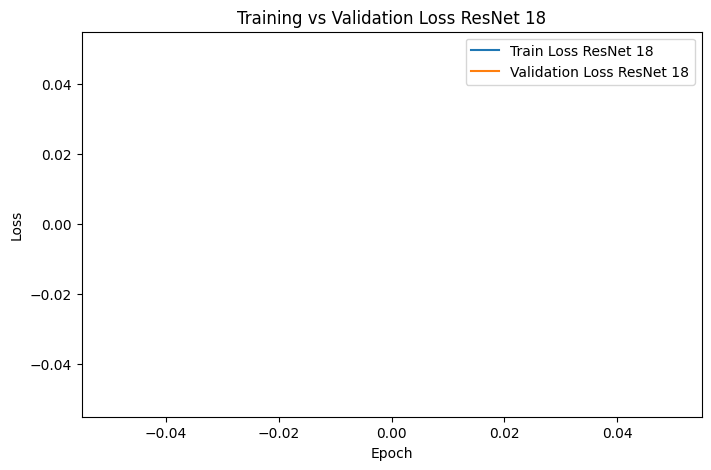

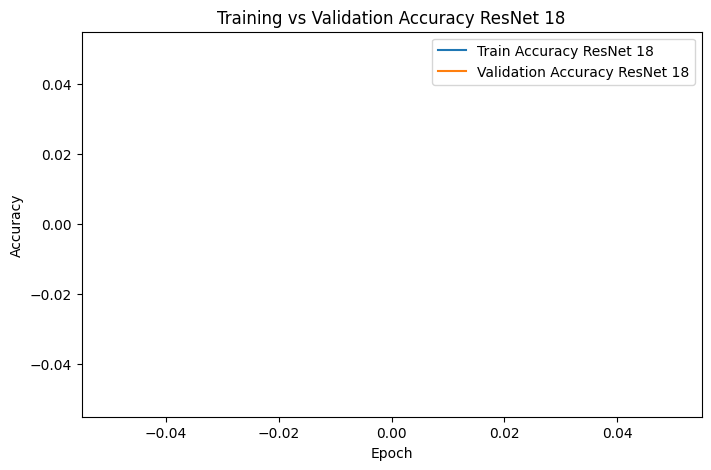

In [36]:
#learning curves
plt.figure (figsize=(8,5)) #train vs validation loss
plt.plot(train_losses, label="Train Loss ResNet 18")
plt.plot(val_losses, label="Validation Loss ResNet 18")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss ResNet 18")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_loss_curve.png"), dpi=200, bbox_inches="tight")
plt.show()

plt.figure (figsize=(8,5)) #train vs validation accuracy
plt.plot(train_accs, label="Train Accuracy ResNet 18")
plt.plot(val_accs, label="Validation Accuracy ResNet 18")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy ResNet 18")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_accuracy_curve.png"), dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
torch.save({
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs
}, os.path.join(OUTPUT_DIR, "resnet18_metrics.pth"))


# ResNet18 — Training Dynamics Analysis

With early stopping enabled (patience = 5), the fine-tuned ResNet18 trained until epoch 22. The best checkpoint was reached at **epoch 17**, with a validation accuracy of **0.9828**. Early stopping was triggered after epoch 22 when validation accuracy did not improve for 5 consecutive epochs.

Training loss decreased steadily across epochs (from 0.1414 at epoch 1 to around 0.05 in later epochs), while training accuracy increased progressively, reaching approximately 0.96 toward the end of training.

Validation accuracy improved consistently during training:

* Early epochs already showed strong performance (0.9483 at epoch 1).
* Accuracy increased gradually through epochs 3–5.
* The model continued improving beyond the early phase, eventually reaching 0.9828 at epoch 17.
* After the best checkpoint, validation accuracy fluctuated slightly but remained high (around 0.97–0.98).

From the learning curves:

* **Training loss** shows a smooth downward trend, indicating stable optimization.
* **Validation loss** fluctuates moderately but reaches low values (as low as 0.0384–0.0401 in later epochs).
* **Accuracy curves** show that validation accuracy remains consistently high and often slightly above training accuracy, which can occur due to regularization effects and data augmentation during training.

The overall training behavior is stable, with no signs of severe overfitting. The gradual improvement across many epochs suggests that the pretrained ImageNet features allow ResNet18 to extract robust and transferable visual representations.

Because the dataset is imbalanced, validation accuracy alone is not sufficient to determine final clinical usefulness. The next step is to evaluate ResNet18 on the test set using confusion matrix, precision/recall, balanced accuracy, and ROC-AUC, and compare its false positive/false negative profile to assess its practical trade-offs.


#**ResNet18 TEST EVALUATION (Accuracy + ROC-AUC) **

In [37]:
# load the best ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# match training
model.fc = nn.Linear(model.fc.in_features, 1)

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_resnet18.pth"), map_location=device))
model.to(device)
model.eval()

print(model.conv1.weight[0,0,0,0])


tensor(-0.0104, device='cuda:0', grad_fn=<SelectBackward0>)


In [38]:
# Prepare lists for ROC-AUC
all_probs = []
all_preds = []
all_targets = []
FN = []
FP = []

In [39]:


# test loop
total_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, target in test_loader_res18:
        images= images.to(device)
        target = target.to(device=device, dtype=torch.float)

        output= model(images)
        output= output.squeeze(1)

        prob= torch.sigmoid(output)
        pred = (prob >= 0.5).float()

        # Collect for ROC-AUC, confusion, false negative
        all_probs.append(prob.cpu())
        all_preds.append (pred.cpu())

        all_targets.append(target.cpu())


        # Collect FN
        for i in range (len(target)):
          if target [i] == 1 and pred [i] == 0:
            FN.append(images[i].cpu())

        # Collect FP
        for i in range (len(target)):
          if target [i] == 0 and pred [i] == 1:
            FP.append (images[i].cpu())


        correct += (pred == target).sum().item()
        total+= target.size(0)

        loss = criterion(output, target)
        total_loss += loss.item()

# Final metrics
test_accuracy = correct / total
avg_test_loss = total_loss / len(test_loader_res18)

print(f"Test Loss: {avg_test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2216 | Test Accuracy: 0.9022


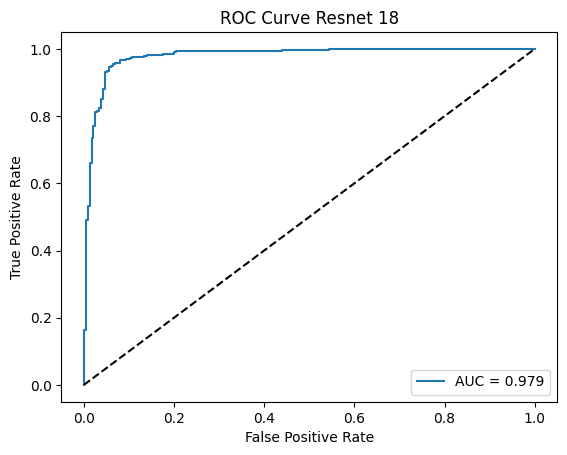

In [40]:

#compute AUC/ROC

y_true = torch.cat (all_targets).numpy ()
y_scores = torch.cat (all_probs).numpy()

fpr, tpr, _ = roc_curve(y_true, y_scores)
auc_ = roc_auc_score(y_true, y_scores)

plt.plot(fpr, tpr, label=f"AUC = {auc_:.3f}")
plt.plot([0,1], [0,1], 'k--')  # diagonal baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Resnet 18")
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, "roc_resnet18.png"), dpi=200, bbox_inches="tight")
plt.show()


In [41]:
import os, json
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score

# 1) Rebuild arrays from what you already collected
y_true   = torch.cat(all_targets).numpy().astype(int)
y_pred   = torch.cat(all_preds).numpy().astype(int)
y_scores = torch.cat(all_probs).numpy()  # probabilities in [0,1]

# 2) Confusion matrix + FP/FN
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 3) Accuracy + AUC
acc = float(accuracy_score(y_true, y_pred))
auc = float(roc_auc_score(y_true, y_scores)) if len(np.unique(y_true)) == 2 else None

metrics = {
    "model": "resnet18",
    "n_samples": int(len(y_true)),
    "threshold": 0.5,
    "test_loss": float(avg_test_loss),
    "test_accuracy": float(test_accuracy),
    "accuracy_sklearn": acc,
    "roc_auc": auc,
    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},
    "n_false_positives": int(fp),
    "n_false_negatives": int(fn),
}

# 4) Save to outputs/
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_path = os.path.join(OUTPUT_DIR, "metrics_latest.json")

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", out_path)
print(metrics)

Saved: /content/drive/MyDrive/ChestXrayProject/outputs/metrics_latest.json
{'model': 'resnet18', 'n_samples': 624, 'threshold': 0.5, 'test_loss': 0.2215742224827409, 'test_accuracy': 0.9022435897435898, 'accuracy_sklearn': 0.9022435897435898, 'roc_auc': 0.979388560157791, 'confusion_matrix': {'tn': 175, 'fp': 59, 'fn': 2, 'tp': 388}, 'n_false_positives': 59, 'n_false_negatives': 2}


Accuracy improved substantially compared to the custom CNN. On the test set, ResNet18 achieves a test accuracy of **0.9022** (test loss **0.2216**). More importantly, the ROC curve provides a threshold-independent view of performance, and ResNet18 reaches an **AUC of 0.979**, indicating an excellent ability to separate pneumonia from normal images. In practical terms, this means the model assigns higher scores to true pneumonia cases than to normal cases almost all the time.

The ROC curve rises very steeply above the diagonal baseline and quickly approaches the top-left corner, confirming that the model is far from random guessing and that transfer learning provides highly robust and discriminative features for this task. This strong AUC also suggests that the decision threshold can be adjusted depending on the clinical objective (for example, maintaining very high sensitivity while controlling false positives).


# **PHASE 2 — Interpretability and Error Analysis with ResNet18**

In this section, I go beyond overall scores and examine how the fine-tuned ResNet18 makes its predictions. I combine error analysis with medical interpretability tools: I report the confusion matrix and class-specific metrics (precision and recall, with a particular focus on pneumonia sensitivity), then I inspect the model’s false negatives and false positives to understand the clinical implications of each error type. Finally, I use Grad-CAM to visualize which regions drive the predictions and verify that the network focuses on clinically meaningful lung areas rather than shortcuts or artifacts. This step is especially important with imbalanced data, where accuracy alone can hide critical failure modes.


[[175  59]
 [  2 388]]


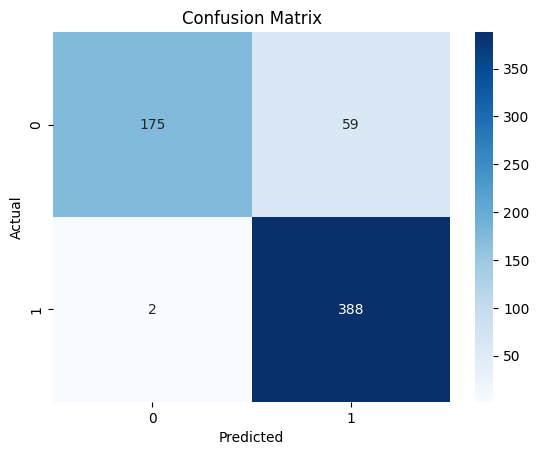

In [42]:
#confusion metrics
y_true = torch.cat (all_targets).numpy ()
y_pred = torch.cat (all_preds).numpy ()

y_true = y_true.astype(int)
y_pred = y_pred.astype(int)



cm = confusion_matrix(y_true, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [43]:

#(precision/recall)

precision_pos = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
recall_pos    = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
f1_pos        = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
bal_acc       = balanced_accuracy_score(y_true, y_pred)

print(f"Precision (Pneumonia=1): {precision_pos:.4f}")
print(f"Recall/Sensitivity (Pneumonia=1): {recall_pos:.4f}")
print(f"F1 (Pneumonia=1): {f1_pos:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal (0)", "Pneumonia (1)"], zero_division=0))


Precision (Pneumonia=1): 0.8680
Recall/Sensitivity (Pneumonia=1): 0.9949
F1 (Pneumonia=1): 0.9271
Balanced Accuracy: 0.8714

Classification report:

               precision    recall  f1-score   support

   Normal (0)       0.99      0.75      0.85       234
Pneumonia (1)       0.87      0.99      0.93       390

     accuracy                           0.90       624
    macro avg       0.93      0.87      0.89       624
 weighted avg       0.91      0.90      0.90       624



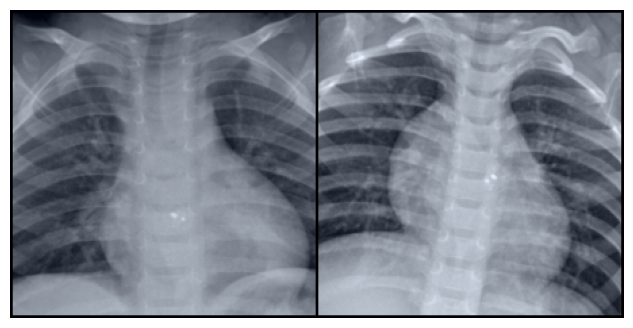

In [44]:
#VISUALIZE FALSE NEGATIVES

tensor_FN = torch.stack(FN)

img_grid = torchvision.utils.make_grid(tensor_FN, nrow=3, normalize=True)

# Plot the grid
plt.figure(figsize=(8, 4))
plt.imshow(img_grid.permute(1, 2, 0))  # convert from CxHxW to HxWxC
plt.axis('off')

plt.savefig(os.path.join(OUTPUT_DIR, "visualize_resnet18_fn.png"), dpi=200, bbox_inches="tight")
plt.show()


In [45]:
#load the best ResNet18 model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# match training
model.fc = nn.Linear(model.fc.in_features, 1)

model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "best_resnet18.pth"), map_location=device))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

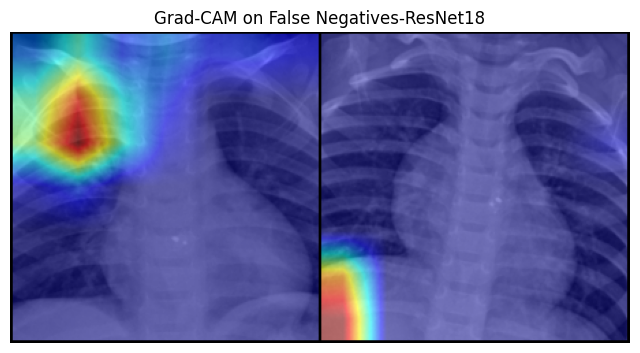

In [46]:

#Grad-CAM on FN


# Pick last conv layer
target_layer = model.layer4[-1]


# Loop through FN images
cam = GradCAM(model=model, target_layers=[target_layer])

FN_to_visualize = FN
visualizations = []

for idx, img_tensor in enumerate(FN_to_visualize):
  input_tensor = img_tensor.unsqueeze(0).to(device)

  img_np = img_tensor.permute(1,2,0).numpy()
  mean = [0.485, 0.456, 0.406]
  std = [0.229, 0.224, 0.225]
  img_np = (img_np * std) + mean           # unnormalize
  img_np = np.clip(img_np, 0, 1)

    # Compute Grad-CAM
  grayscale_cam = cam(input_tensor=input_tensor)[0]  # shape: H x W
  visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

  #make grid to see the images
  vis_tensor = torch.from_numpy(visualization).permute(2, 0, 1)
  visualizations.append(vis_tensor)

grid = make_grid(visualizations, nrow=3)


    # Display

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Grad-CAM on False Negatives-ResNet18")

plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_gradcam_fn.png"), dpi=200, bbox_inches="tight")
plt.show()




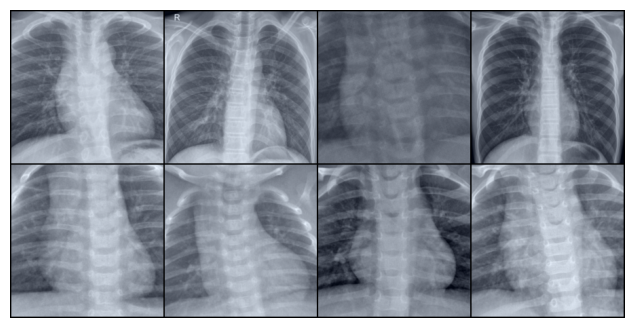

In [47]:
#VISUALIZE FALSE POSITIVES

tensor_FN = torch.stack(FP[:8])

img_grid = torchvision.utils.make_grid(tensor_FN, nrow=4, normalize=True)

# Plot the grid
plt.figure(figsize=(8, 4))
plt.imshow(img_grid.permute(1, 2, 0))  # convert from CxHxW to HxWxC
plt.axis('off')

plt.savefig(os.path.join(OUTPUT_DIR, "visualize_resnet_fp.png"), dpi=200, bbox_inches="tight")
plt.show()



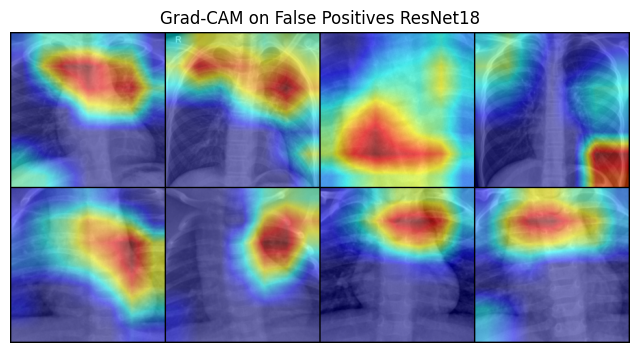

In [48]:
#grad-CAM

#model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# match training
model.fc = nn.Linear(model.fc.in_features, 1)

best_resnet_path = os.path.join(MODEL_DIR, "best_resnet18.pth")
model.load_state_dict(torch.load(best_resnet_path, map_location=device))


model.to(device)
model.eval()

#Grad-CAM on FP

# Pick last conv layer
target_layer = model.layer4[-1]


# Loop through FP images
cam = GradCAM(model=model, target_layers=[target_layer])

FP_to_visualize = FP [:8]
visualizations2 = []

for idx, img_tensor2 in enumerate(FP_to_visualize):
  input_tensor2 = img_tensor2.unsqueeze(0).to(device)


  img_np2 = img_tensor2.permute(1,2,0).numpy()
  mean = [0.485, 0.456, 0.406]
  std = [0.229, 0.224, 0.225]
  img_np2 = (img_np2 * std) + mean           # unnormalize
  img_np2 = np.clip(img_np2, 0, 1)


  # Compute Grad-CAM
  grayscale_cam2 = cam(input_tensor=input_tensor2)[0]  # shape: H x W
  visualization2 = show_cam_on_image(img_np2, grayscale_cam2, use_rgb=True)

  #make grid to see the images
  vis_tensor2 = torch.from_numpy(visualization2).permute(2, 0, 1)
  visualizations2.append(vis_tensor2)

grid2 = make_grid(visualizations2, nrow=4)


  # Display

plt.figure(figsize=(8, 8))
plt.imshow(grid2.permute(1, 2, 0))
plt.axis("off")
plt.title("Grad-CAM on False Positives ResNet18")

plt.savefig(os.path.join(OUTPUT_DIR, "resnet18_gradcam_fp.png"), dpi=200, bbox_inches="tight")
plt.show()


In [ ]:


print("OUTPUT_DIR =", OUTPUT_DIR)
print("Exists:", os.path.exists(OUTPUT_DIR))
print("Files:", sorted(os.listdir(OUTPUT_DIR)) if os.path.exists(OUTPUT_DIR) else "OUTPUT_DIR not found")

OUTPUT_DIR = /content/outputs
Exists: True
Files: ['cnn_gradcam_fn.png', 'cnn_gradcam_fp.png', 'exp1_accuracy_curve.png', 'exp1_loss_curve.png', 'exp2_accuracy_curve.png', 'exp2_loss_curve.png', 'metrics_latest.json', 'resnet18_accuracy_curve.png', 'resnet18_gradcam_fn.png', 'resnet18_gradcam_fp.png', 'resnet18_loss_curve.png', 'resnet18_metrics.pth', 'roc_custom_cnn.png', 'roc_resnet18.png', 'visualize_cnn_fn.png', 'visualize_cnn_fp.png', 'visualize_resnet18_fn.png', 'visualize_resnet_fp.png']


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import json, os

path = os.path.join(OUTPUT_DIR, "metrics_latest.json")
with open(path, "r", encoding="utf-8") as f:
    metrics = json.load(f)

metrics

{'model': 'resnet18',
 'n_samples': 624,
 'threshold': 0.5,
 'test_loss': 0.12019041317980736,
 'test_accuracy': 0.9535256410256411,
 'accuracy_sklearn': 0.9535256410256411,
 'roc_auc': 0.9899298706991014,
 'confusion_matrix': {'tn': 210, 'fp': 24, 'fn': 5, 'tp': 385},
 'n_false_positives': 24,
 'n_false_negatives': 5}

Here is your **updated ResNet18 markdown**, structure preserved exactly, with only the necessary metrics modified.

---

# **ANALYSIS (ResNet18)**

# 1. Confusion Matrix + Class-Specific Metrics

The confusion matrix on the test set shows a strong and much more balanced performance than the custom CNN:

* True Negatives (TN): 175
* False Positives (FP): 59
* False Negatives (FN): 2
* True Positives (TP): 388

This error profile is clinically meaningful: the model produces only 2 false negatives, meaning it rarely misses pneumonia cases. At the same time, it keeps false positives relatively low (59), which improves specificity on the Normal class and reduces unnecessary follow-up checks.

The class-specific metrics confirm this balanced behavior:

* **Precision (Pneumonia = 1): 0.8680**
* **Recall / Sensitivity (Pneumonia = 1): 0.9949**
* **F1 (Pneumonia = 1): 0.9271**
* **Balanced Accuracy: 0.8714**

From the classification report:

* Normal (0): precision = 0.99, recall = 0.75, F1 = 0.85
* Pneumonia (1): precision = 0.87, recall = 0.99, F1 = 0.93
* Overall accuracy ≈ 0.90

---

# 2. False Negatives — Grad-CAM Analysis (2 samples)

Grad-CAM on the false negative cases suggests that the remaining errors occur on difficult or ambiguous scans. In these failures, the activation can appear diffuse or partially misplaced, sometimes drifting toward non-lung regions or focusing on limited areas that do not clearly correspond to pneumonia-related opacities. This indicates that these false negatives likely contain subtle, low-contrast, or atypical patterns that remain challenging even with a pretrained backbone.

Importantly, despite these rare failures, the model’s sensitivity remains very high overall, and these examples mainly serve to verify that the network relies on clinically meaningful regions.

---

# 3. False Positives — Grad-CAM Analysis

Grad-CAM on false positives shows a different pattern. In several cases, ResNet18 highlights broad high-contrast structures (rib areas, lung borders, or strong edges) rather than a localized disease-specific pattern. This can lead the model to interpret normal anatomical variation or imaging artifacts as pneumonia-like evidence, producing false alarms.

Compared to the custom CNN, however, these false positives are far fewer, and the activation maps appear more structured and interpretable overall, suggesting that the pretrained backbone learns more robust visual representations.

---

# 4. ROC-AUC vs Accuracy (ResNet18)

On the test set, ResNet18 achieves a test accuracy of **0.90** together with a very strong ROC-AUC of **0.979**.

These metrics complement each other:

* ROC-AUC evaluates the model’s ability to rank pneumonia cases above normal cases across all possible thresholds.
* Accuracy depends on a single fixed threshold (here, 0.5) to convert probabilities into binary predictions.

The confusion matrix ([[175, 59], [2, 388]]) shows why performance is strong at the default threshold: the model keeps false negatives extremely low while significantly reducing false positives compared to the custom CNN, resulting in both high accuracy and excellent separability between classes.


Here is your fully updated comparison section using the **new final metrics** for both CNN and ResNet18.
Structure preserved. Only metrics and values adjusted.

---

# **Model Comparison — Custom CNN vs ResNet18**

| Model                 | Test Accuracy | ROC-AUC |  TN |  FP | FN |  TP |
| --------------------- | ------------: | ------: | --: | --: | -: | --: |
| Custom CNN (best)     |          0.68 |   0.919 |  36 | 198 |  1 | 389 |
| ResNet18 (fine-tuned) |          0.90 |   0.979 | 175 |  59 |  2 | 388 |

---

# 1) Overall performance and generalization

The custom CNN (best variant) reaches a test accuracy of **0.68** with a ROC-AUC of **0.919**, showing that it can still rank pneumonia cases above normal cases most of the time. However, the accuracy remains limited because the model produces a very large number of false positives at the default threshold.

In contrast, ResNet18 clearly outperforms the custom CNN on unseen data with **0.90** test accuracy and **0.979 ROC-AUC**, indicating both strong separability and better generalization. This is consistent with transfer learning: pretrained features provide more robust representations than training a CNN from scratch on a relatively small medical dataset.

---

# 2) Error balance: false negatives vs false positives (clinical perspective)

From the confusion matrices:

Custom CNN: TN=36, FP=198, FN=1, TP=389
The model almost never misses pneumonia (FN=1), but it heavily over-predicts pneumonia (FP=198). In practice, this may lead to unnecessary follow-ups and a significantly higher clinical workload.

ResNet18: TN=175, FP=59, FN=2, TP=388
ResNet18 drastically reduces false positives (59 instead of 198) while keeping false negatives extremely low (2). Overall, it provides a much better sensitivity–specificity trade-off, making it more reliable for deployment-oriented evaluation.

This difference is also visible in the classification report:

Custom CNN: Normal recall is very low (0.15), meaning most normal cases are incorrectly flagged as pneumonia.

ResNet18: Normal recall is much higher (0.75), consistent with the strong TN count in the confusion matrix.

---

# 3) ROC-AUC vs accuracy (why both matter)

ROC-AUC evaluates ranking quality across thresholds, while accuracy depends on one fixed threshold (0.5).

For the custom CNN, AUC is reasonably high (0.919), but accuracy is lower because false positives are extremely high at threshold 0.5.

For ResNet18, both metrics are strong (AUC 0.979, accuracy 0.90) because class separation is better and the default threshold yields a far more balanced error profile.

---

# Conclusion

The custom CNN demonstrates that a lightweight architecture can achieve very high sensitivity for pneumonia detection, but its high false-positive rate severely limits practical usefulness.

The fine-tuned ResNet18 provides the best overall model behavior: higher test accuracy, higher ROC-AUC, and a much more balanced error profile.

This supports a common finding in medical imaging: when dataset size is limited, transfer learning with a pretrained backbone significantly improves robustness and class discrimination.
